# 2 Analysis and visualization

#### Resources

- https://wencke.github.io/
- https://geneontology.org/docs/downloads/

## Setup

### Load libraries

In [25]:
library(colorspace)
library(readxl)
library(openxlsx)
library(ggrepel)
library(scales)
library(patchwork)
library(RColorBrewer)
library(clusterProfiler)
library(ontologyIndex)
library(tidygraph)
library(ggraph)
library(tidyverse)   
library(igraph)
library(tidyverse)
library(svglite)
library(IRdisplay)
library(ggh4x)
library(tibble)

options(warn = -1)

### Set working directory

In [ ]:
wd <- "/path/to/01_transcriptomics"
setwd(wd)

### Define functions

In [3]:
# Mix elements from middle, start, and end
mix_elements <- function(vec) {
  n <- length(vec)
  mixed <- numeric(n)
  mid <- ceiling(n / 2)
  i <- 1
  rem <- vec
  
  while (i <= n) {
    if (length(rem) >= 1 && mid <= length(rem)) {
      mixed[i] <- rem[mid]; rem <- rem[-mid]; i <- i + 1
    }
    if (i <= n && length(rem) >= 1) {
      mixed[i] <- rem[1]; rem <- rem[-1]; i <- i + 1
    }
    if (i <= n && length(rem) >= 1) {
      mixed[i] <- rem[length(rem)]; rem <- rem[-length(rem)]; i <- i + 1
    }
  }
  mixed
}

# Wrap text to fit ideal width and max lines
wrap_text_custom <- function(text, ideal_width, max_lines = 3) {
  text <- str_replace_all(text, "\\([^()]*\\)", "")
  words <- str_split(text, " ")[[1]]
  
  if (length(words) == 2 && nchar(text) <= ideal_width)
    return(paste(words, collapse = "\n"))
  
  lines <- c(); current <- ""
  for (w in words) {
    if (nchar(current) + nchar(w) + 1 > ideal_width) {
      if (length(lines) + 1 == max_lines) {
        current <- paste(current, paste(words[which(words == w):length(words)], collapse = " "))
        break
      }
      lines <- c(lines, str_trim(current)); current <- w
    } else {
      current <- paste(current, w)
    }
  }
  lines <- c(lines, str_trim(current))
  paste(head(lines, max_lines), collapse = "\n")
}


### Define thresholds

In [4]:
pvalueTH <- 0.05
log2fcTH <- 2

### Define colors

In [5]:
# Color palettes for gene regulation
down_colors <- brewer.pal(9, "Blues")
up_colors   <- brewer.pal(9, "Reds")

change_colors <- c(
  down    = down_colors[4],
  up      = up_colors[4],
  none    = "darkgrey",
  neutral = "darkgrey"
)

change_colors_dark <- c(
  down_dark = down_colors[8],
  up_dark   = up_colors[8],
  none      = "none_dark"
)


### Load gene information

In [6]:
gene_info <- read_excel(file.path(wd, "02_data/tables/annotation/genes/gene_information_new.xls")) %>%
  setNames(make.names(names(.), unique = TRUE)) %>%
  rename(
    gene_id       = GENE.ID,
    gene_name     = Gene.Name,
    gene_synonym  = Synonyms,
    gene_products = Gene.products
  )


### Load GO-Term table

Parse go-basic.obo obtained from from https://geneontology.org/docs/download-ontology/

In [7]:
# Assign GO category based on top-level ancestor terms
get_category <- function(ancestors) {
  if (grepl("GO:0008150", ancestors)) {
    return("BP")  # Biological Process
  } else if (grepl("GO:0005575", ancestors)) {
    return("CC")  # Cellular Component
  } else if (grepl("GO:0003674", ancestors)) {
    return("MF")  # Molecular Function
  } else {
    return(NA_character_)
  }
}

# Path to GO OBO file
go_file_path <- file.path(wd, "02_data/tables/GO/go-basic.obo")

# Parse ontology and extract core structure
obo_file <- get_ontology(
  go_file_path,
  propagate_relationships = "is_a",
  extract_tags = "minimal",
  merge_equivalent_terms = TRUE
)

# Create tidy GO term table
go_table <- as.data.frame(obo_file) %>%
  select(id, name, parents, children, ancestors, obsolete) %>%
  rename(GOID = id, Name = name) %>%
  mutate(category = sapply(ancestors, get_category)) %>%
  filter(!is.na(category))

# Remove row names for clarity
rownames(go_table) <- NULL


### Parse DictyGO gene relations

In [8]:
# Load GAF file and extract gene-GO relations
gaf_file <- file.path(wd, "02_data/tables/annotation/TopGO/dictybase.gaf")

gaf_data <- read.delim(
  gaf_file,
  comment.char = "!",
  header = FALSE,
  sep = "\t",
  quote = "",
  stringsAsFactors = FALSE
)

colnames(gaf_data) <- c(
  "DB", "DB_Object_ID", "DB_Object_Symbol", "Qualifier", "GO_ID", 
  "DB_Reference", "Evidence_Code", "With_or_From", "Aspect", 
  "DB_Object_Name", "DB_Object_Synonym", "DB_Object_Type", 
  "Taxon", "Date", "Assigned_By", "Annotation_Extension", "Gene_Product_Form_ID"
)

write.csv(
  gaf_data,
  file.path(wd, "02_data/tables/annotation/TopGO/DictyBase_GO_Terms_Full.csv"),
  row.names = FALSE
)

dictyGO_list <- unique(gaf_data$GO_ID)

genes2GO_raw <- gaf_data %>%
  select(DB_Object_ID, GO_ID) %>%
  rename(gene_id = DB_Object_ID, TermID = GO_ID) %>%
  distinct()


### Combine gene information with GO data  
Join and structure data by GO category for downstream analyses

In [9]:
# Join GO categories to gene-GO links
genes2GO <- merge(genes2GO_raw, go_table, by.x = "TermID", by.y = "GOID", all.x = TRUE)

# Subset gene-GO mappings by category
genes2GO_CC <- genes2GO %>% filter(category == "CC") %>% select(TermID, gene_id)
genes2GO_MF <- genes2GO %>% filter(category == "MF") %>% select(TermID, gene_id)
genes2GO_BP <- genes2GO %>% filter(category == "BP") %>% select(TermID, gene_id)

# Extract GO term tables by category
GO2Term    <- genes2GO %>% select(TermID, Name, category) %>% distinct()
GO2TermsCC <- GO2Term %>% filter(category == "CC") %>% select(-category)
GO2TermsMF <- GO2Term %>% filter(category == "MF") %>% select(-category)
GO2TermsBP <- GO2Term %>% filter(category == "BP") %>% select(-category)

## PCA
PCA visualization of transcriptomic variation across genotypes (wt vs disfp–) in three developmental stages

### Setup

In [10]:
# Sample metadata and color setup
genotype <- c("wt", "wt", "wt", "ko", "ko", "ko")
data_matrix_colnames <- c("  wt 1  ", "  wt 2  ", "  wt 3  ", "  ko 1  ", "  ko 2  ", "  ko 3  ")

wt_colors     <- brewer.pal(n = 9, name = "Greens")
disfp_colors  <- brewer.pal(n = 9, name = "Purples")
rescue_colors <- brewer.pal(n = 9, name = "Blues")

strain_colors       <- c("wt" = wt_colors[6], "ko" = disfp_colors[6])
strain_colors_light <- c("wt" = wt_colors[3], "ko" = disfp_colors[3])

group_labels <- c("wt", "wt", "wt", "ko", "ko", "ko")
annotation_col <- data.frame(Group = group_labels)
rownames(annotation_col) <- data_matrix_colnames

annotation_colors <- list(Group = strain_colors)


### Plot

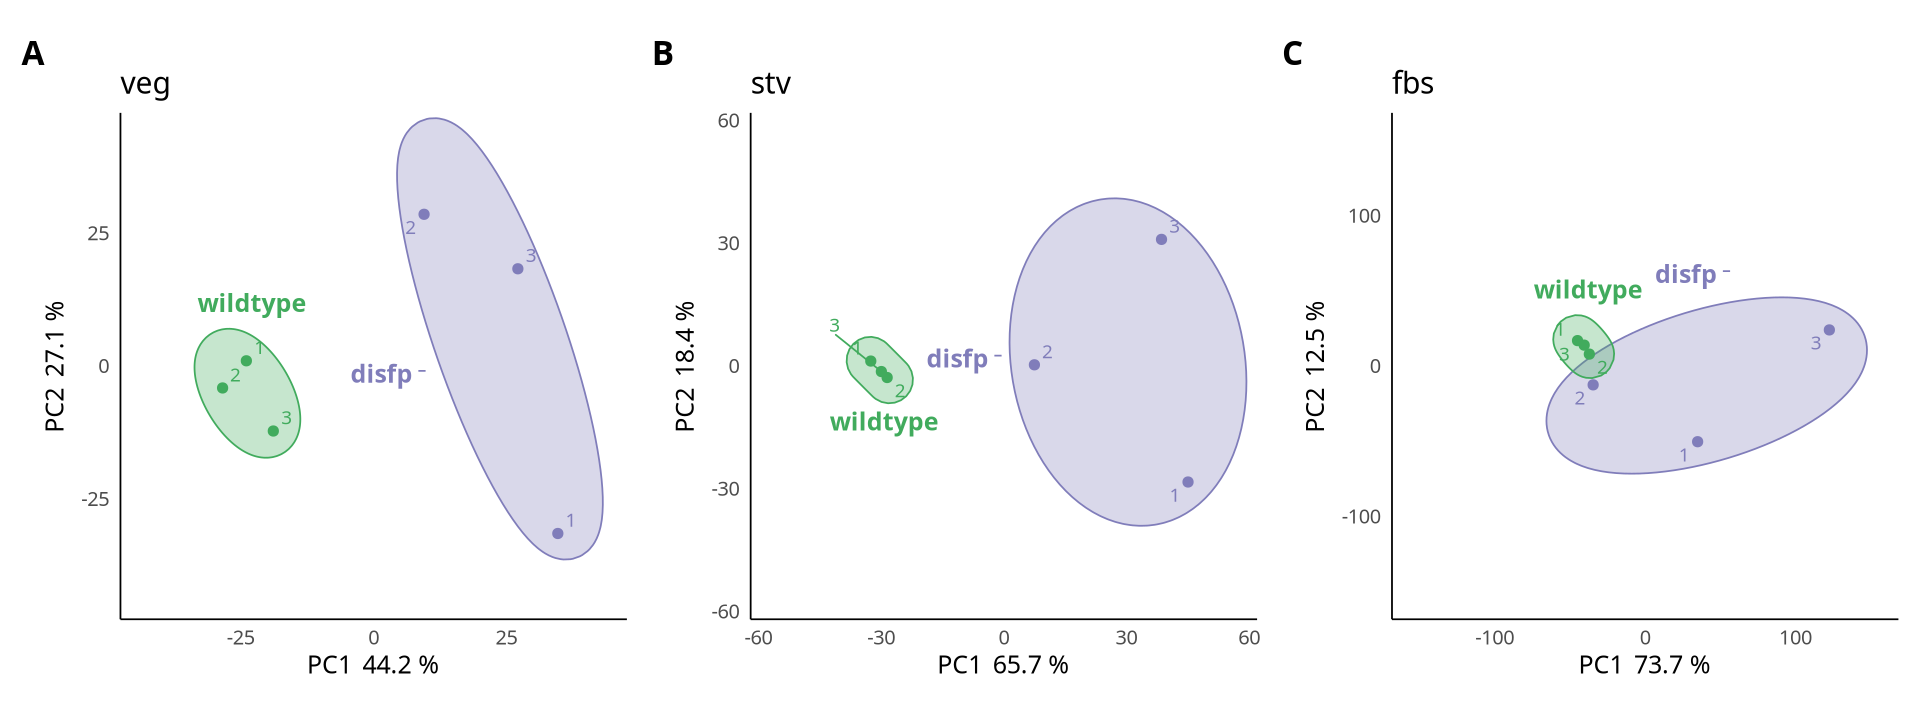

In [11]:
# Loop PCA across developmental stages; store plots in a list for combined visualization
stages <- c("veg", "stv", "fbs")
pca_plots <- list()

for (stage in stages) {
  
  # Load normalized expression data
  df_filePath <- file.path(wd, "02_data", "tables", "raw", stage, "condition-wt-mutant.vst.tsv")
  df_raw <- read_tsv(df_filePath, show_col_types = FALSE)
  colnames(df_raw)[-1] <- data_matrix_colnames  # Replace column names

  # Merge gene names and build matrix
  df_named <- df_raw %>%
    left_join(gene_info %>% select(gene_id, gene_name), by = "gene_id") %>%
    filter(!is.na(gene_name)) %>%
    column_to_rownames("gene_name") %>%
    select(-gene_id)
  
  df_pca_input <- t(df_named)
  
  # PCA
  PCA <- prcomp(df_pca_input, center = TRUE, scale. = FALSE)
  variance <- round((PCA$sdev^2) * 100 / sum(PCA$sdev^2), 1)
  
  pca_df <- as.data.frame(PCA$x)[, 1:2]
  colnames(pca_df) <- c("PC1", "PC2")
  pca_df$genotype <- genotype
  pca_df$sample_name <- gsub("\\D", "", rownames(pca_df))

  # Plot limits
  coord_sf <- 1.25
  max_limit <- max(abs(c(pca_df$PC1, pca_df$PC2))) * coord_sf

  # Build PCA plot
  pca_plot <- ggplot(pca_df, aes(x = PC1, y = PC2, colour = genotype)) +
    ggforce::geom_mark_ellipse(
      aes(fill = genotype, color = genotype, filter = genotype == "ko", label = "disfp\u2009\u207B"),
      label.colour = strain_colors[["ko"]], con.type = "none", label.buffer = unit(-2, "mm"), label.fontsize = 15, label.fill = NA
    ) +
    ggforce::geom_mark_ellipse(
      aes(fill = genotype, color = genotype, filter = genotype == "wt", label = "wildtype"),
      label.colour = strain_colors[["wt"]], con.type = "none", label.buffer = unit(-2, "mm"), label.fontsize = 15, label.fill = NA
    ) +
    geom_point(size = 2.5) +
    ggrepel::geom_text_repel(aes(label = sample_name), size = 4, max.overlaps = Inf) +
    scale_fill_manual(values = strain_colors) +
    scale_color_manual(values = strain_colors) +
    xlab(paste("PC1", variance[1], "%")) +
    ylab(paste("PC2", variance[2], "%")) +
    ggtitle(stage) +
    theme_minimal(base_size = 15) +
    theme(
      title = ggtext::element_markdown(),
      panel.grid = element_blank(),
      legend.position = "none",
      axis.line = element_line(size = 0.5, color = "black")
    ) +
    coord_fixed(ratio = 1, xlim = c(-max_limit, max_limit), ylim = c(-max_limit, max_limit))

  # Store plot
  pca_plots[[stage]] <- pca_plot
}

# Combine plots side-by-side with patchwork
options(repr.plot.width = 16, repr.plot.height = 6)
pca_plots$veg + pca_plots$stv + pca_plots$fbs +
  plot_layout(ncol = 3) +
  plot_annotation(tag_levels = "A") &
  theme(plot.tag = element_text(size = 20, face = "bold"))


## Differential expression and gene ontology analysis  
Define input paths for differential expression results by developmental stage

In [12]:
stages_paths_list <- list(
  veg = "02_data/tables/diffAbs/veg/differential/condition-wt-mutant.deseq2.results.tsv",
  agg = "02_data/tables/diffAbs/agg/differential/condition-wt-mutant.deseq2.results.tsv",
  fbs = "02_data/tables/diffAbs/fbs/differential/condition-wt-mutant.deseq2.results.tsv"
)


### Function for GO and KEGG enrichment analysis by stage  
Runs differential expression analysis and performs GO and KEGG enrichment across developmental stages

In [13]:
runGOAnalysisForAll <- function(stages_paths_list) {
  results <- list()
  
  for (stage in names(stages_paths_list)) {
    file_path <- stages_paths_list[[stage]]
    diff_df_raw <- read_tsv(file_path, show_col_types = FALSE)

    # Classify DE genes into up/down/none and GO-specific direction
    diff_df <- diff_df_raw %>%
      mutate(
        change = case_when(
          log2FoldChange <= -log2fcTH & pvalue <= pvalueTH ~ "down",
          log2FoldChange >=  log2fcTH & pvalue <= pvalueTH ~ "up",
          TRUE ~ "none"
        ),
        change_GO = case_when(
          log2FoldChange <= 0 & pvalue <= pvalueTH ~ "down",
          log2FoldChange >= 0 & pvalue <= pvalueTH ~ "up",
          TRUE ~ "none"
        ),
        change = factor(change, levels = c("up", "down", "none"))
      ) %>%
      arrange(desc(change), padj)

    # Add gene annotations
    diff_df <- merge(diff_df, gene_info, by = "gene_id", all.x = TRUE) %>%
      mutate(
        gene_name = ifelse(is.na(gene_name), gene_id, gene_name),
        gene_products = na_if(gene_products, ""),
        gene_synonym  = na_if(gene_synonym, ""),
        gene_name_filled = case_when(
          !is.na(gene_products) & grepl("TRE", gene_products)     ~ "TRE",
          !is.na(gene_products) & grepl("Skipper", gene_products) ~ "Skipper",
          TRUE ~ gene_name
        ),
        gene_name_filled = sub(",.*$", "", gene_name_filled)
      ) %>%
      mutate(gene_name_filled_full = ifelse(grepl("DDB_", gene_name) & !is.na(gene_products), gene_products, gene_name), gene_name_filled_full = sub(",.*$", "", gene_name_filled_full))

    # Attach GO terms to differential table
    diff_df_go <- inner_join(diff_df, genes2GO_raw, by = "gene_id") %>%
      rename(GOTerms = TermID)

    # Define gene universe and significant genes
    sig_genes <- diff_df %>% filter(pvalue < 0.05) %>% pull(gene_id)
    universe_genes <- diff_df$gene_id

    # GO enrichment by ontology
    enrich_results_CC <- enricher(sig_genes, universe = universe_genes, TERM2GENE = genes2GO_CC, TERM2NAME = GO2TermsCC, pvalueCutoff = 0.05, pAdjustMethod = "BH", minGSSize = 5)
    enrich_results_MF <- enricher(sig_genes, universe = universe_genes, TERM2GENE = genes2GO_MF, TERM2NAME = GO2TermsMF, pvalueCutoff = 0.05, pAdjustMethod = "BH", minGSSize = 5)
    enrich_results_BP <- enricher(sig_genes, universe = universe_genes, TERM2GENE = genes2GO_BP, TERM2NAME = GO2TermsBP, pvalueCutoff = 0.05, pAdjustMethod = "BH", minGSSize = 5)

    # Merge enrichment results into main dataframe
    diff_df_GO_CC <- merge(diff_df_go, enrich_results_CC@result %>% select(-geneID) %>% mutate(category = "CC") %>% rename(GOTerms = ID, Fisher = pvalue, FisherAdj = p.adjust), by = "GOTerms", all.x = TRUE)
    diff_df_GO_MF <- merge(diff_df_go, enrich_results_MF@result %>% select(-geneID) %>% mutate(category = "MF") %>% rename(GOTerms = ID, Fisher = pvalue, FisherAdj = p.adjust), by = "GOTerms", all.x = TRUE)
    diff_df_GO_BP <- merge(diff_df_go, enrich_results_BP@result %>% select(-geneID) %>% mutate(category = "BP") %>% rename(GOTerms = ID, Fisher = pvalue, FisherAdj = p.adjust), by = "GOTerms", all.x = TRUE)

    # Combine GO annotations from all categories
    diff_df_GO_all <- bind_rows(diff_df_GO_CC, diff_df_GO_MF, diff_df_GO_BP) %>%
      filter(!is.na(Description), change_GO != "none")

    # Count up/down-regulated genes per GO term and compute z-score
    counts <- diff_df_GO_all %>%
      group_by(category, GOTerms) %>%
      summarise(
        up_count = sum(change_GO == "up"),
        down_count = sum(change_GO == "down"),
        total_count = n(),
        .groups = "drop"
      ) %>%
      mutate(
        z_score = (up_count - down_count) / total_count,
        z_score_change = case_when(
          z_score > 0.25  ~ "up",
          z_score < -0.25 ~ "down",
          TRUE            ~ "neutral"
        )
      )

    # Join z-scores and prepare GOplot-compatible table
    diff_df_GO_all <- left_join(diff_df_GO_all, counts, by = c("GOTerms", "category"))

    Goplot_df <- diff_df_GO_all %>%
      select(category, GOTerms, Description, Count, gene_id, gene_name_filled, log2FoldChange, FisherAdj, z_score) %>%
      rename(
        ID         = GOTerms,
        term       = Description,
        count      = Count,
        genes      = gene_id,
        genes_name = gene_name_filled,
        logFC      = log2FoldChange,
        adj_pval   = FisherAdj,
        zscore     = z_score
      ) %>%
      arrange(category, adj_pval)

    # KEGG enrichment (assumes gene IDs are KEGG compatible)
    enrich_results_KEGG <- enrichKEGG(
      gene         = sig_genes,
      organism     = "ddi",
      keyType      = "kegg",
      universe     = universe_genes,
      pAdjustMethod = "none",
      pvalueCutoff = 0.01
    )

    # Store per-stage results
    results[[stage]] <- list(
      diffEx_df    = diff_df,
      GOall_df     = diff_df_GO_all,
      GOplot_df    = Goplot_df,
      KEGG_reults  = enrich_results_KEGG
    )
  }

  return(results)
}


### Call enrichment function  
Run GO and KEGG enrichment for all defined developmental stages

In [ ]:
results <- runGOAnalysisForAll(stages_paths_list)


## Vulcano plots  
Generate volcano plots for differential expression across all developmental stages

In [ ]:
# Volcano Plot Function with Vertical Label Layout & Multiple Lines for Duplicates
vulcano_plot <- function(vulcano_df, max_log2FC, max_pvalue, title, 
                         yaxis_label, legend, slot_offset) {
  top_number <- 10
  
  top_genes_pv <- vulcano_df %>%
    filter(!str_detect(gene_name_filled, "DDB_"), gene_name_filled != "unknown") %>%
    filter(change %in% c("up", "down")) %>%
    group_by(change) %>% arrange(padj) %>% slice_head(n = top_number) %>% ungroup()
  
  top_genes_logpos <- vulcano_df %>%
    filter(!str_detect(gene_name_filled, "DDB_"), gene_name_filled != "unknown", change == "up") %>%
    arrange(desc(log2FoldChange)) %>% slice_head(n = top_number)
  
  top_genes_logneg <- vulcano_df %>%
    filter(!str_detect(gene_name_filled, "DDB_"), gene_name_filled != "unknown", change == "down") %>%
    arrange(log2FoldChange) %>% slice_head(n = top_number)

  top_genes <- bind_rows(top_genes_logneg, top_genes_logpos, top_genes_pv) %>%
    distinct(gene_name, .keep_all = TRUE)

  vulcano_df <- vulcano_df %>%
    mutate(change = factor(change, levels = c("up", "down", "none"))) %>%
    filter(!is.na(log2FoldChange), !is.na(padj))

  rounded_limit <- ceiling(max_log2FC / 2) * 2
  down_colors <- brewer.pal(9, "Blues")
  up_colors   <- brewer.pal(9, "Reds")
  change_colors <- c("down" = down_colors[5], "up" = up_colors[5], "none" = "darkgrey")
  change_colors_dark <- c("down_dark" = down_colors[8], "up_dark" = up_colors[8], "none_dark" = "grey60")
  
  label_data_up_grouped <- top_genes %>%
    filter(change == "up") %>%
    group_by(gene_name_filled) %>% slice_min(padj, with_ties = FALSE) %>%
    ungroup() %>% arrange(padj)
  
  label_data_down_grouped <- top_genes %>%
    filter(change == "down") %>%
    group_by(gene_name_filled) %>% slice_min(padj, with_ties = FALSE) %>%
    ungroup() %>% arrange(padj)
  
  minY <- -log10(pvalueTH) * 1.8
  maxY <- max(-log10(vulcano_df$padj), na.rm = TRUE)
  y_slots <- seq(from = maxY, to = minY, length.out = 20)
  
  n_up <- nrow(label_data_up_grouped)
  n_down <- nrow(label_data_down_grouped)
  
  label_data_up_grouped <- label_data_up_grouped %>%
    mutate(x_label = rounded_limit * 0.8, y_label = y_slots[(floor((20 - n_up) / 2) + 1 - slot_offset):(floor((20 - n_up) / 2) + n_up - slot_offset)])
  
  label_data_down_grouped <- label_data_down_grouped %>%
    mutate(x_label = -rounded_limit * 0.8, y_label = y_slots[(floor((20 - n_down) / 2) + 1 - slot_offset):(floor((20 - n_down) / 2) + n_down - slot_offset)])
  
  label_data_grouped <- bind_rows(label_data_up_grouped, label_data_down_grouped)

  label_data_ungrp <- top_genes %>%
    filter(change %in% c("up", "down")) %>%
    left_join(label_data_grouped %>% select(gene_name_filled, x_label, y_label, change),
              by = c("gene_name_filled", "change"))

  ggplot(vulcano_df, aes(x = log2FoldChange, y = -log10(padj), fill = change)) +
    geom_segment(aes(x = -log2fcTH, xend = -log2fcTH, y = -Inf, yend = Inf), color = "grey50", size = 0.05) +
    geom_segment(aes(x =  log2fcTH, xend =  log2fcTH, y = -Inf, yend = Inf), color = "grey50", size = 0.05) +
    geom_segment(aes(x = -Inf, xend = Inf, y = -log10(pvalueTH), yend = -log10(pvalueTH)), color = "grey50", size = 0.05) +
    geom_segment(data = label_data_ungrp,
                 aes(x = log2FoldChange, y = -log10(padj),
                     xend = x_label - 0.035 * x_label, yend = y_label,
                     color = paste0(change, "_dark")),
                 alpha = 0.2, size = 0.15, linetype = "solid", inherit.aes = FALSE) +
    geom_point(shape = 21, stroke = NA, size = 0.9) +
    geom_point(data = top_genes,
               aes(x = log2FoldChange, y = -log10(padj), color = paste0(change, "_dark")),
               shape = 21, stroke = 0.25, size = 0.9, show.legend = FALSE) +
    geom_text(data = label_data_grouped,
              aes(x = x_label, y = y_label, label = gene_name_filled, color = paste0(change, "_dark")),
              size = 2, hjust = ifelse(label_data_grouped$change == "up", 0, 1),
              inherit.aes = FALSE) +
    scale_fill_manual(values = change_colors) +
    scale_color_manual(values = c(change_colors_dark, "up" = up_colors[5], "down" = down_colors[5], "none" = "darkgrey")) +
    scale_x_continuous(limits = c(-1.25 * rounded_limit, 1.25 * rounded_limit), breaks = pretty_breaks(n = 5)) +
    scale_y_continuous(limits = c(0, NA), breaks = pretty_breaks(n = 4)) +
    labs(
      x = expression(log[2] * "(fold-change)"),
      y = if (yaxis_label) bquote(-log[10] ~ "(" * italic("p") * "-value)") else NULL,
      fill = "Differential expression"
    ) +
    ggtitle(title) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid = element_blank(),
      legend.justification = c("right", "top"),
      legend.background = element_rect(fill = alpha('white', 0.7), color = "grey90"),
      legend.margin = margin(10, 20, 10, 20),
      legend.position = if (legend) c(0.99, 0.99) else "none"
    ) +
    coord_cartesian(clip = "off")
}

# Calculate global maxima for consistent scaling
all_padj_values <- unlist(lapply(results, \(x) if (!is.null(x$diffEx_df)) -log10(x$diffEx_df$padj)))
max_padj_all <- max(all_padj_values, na.rm = TRUE)

all_log2fc_values <- unlist(lapply(results, \(x) if (!is.null(x$diffEx_df)) x$diffEx_df$log2FoldChange))
max_abs_log2fc <- max(abs(all_log2fc_values), na.rm = TRUE)

# Compose 3-panel plot
options(repr.plot.width = 25, repr.plot.height = 10)
vulcano_patchwork <- 
  vulcano_plot(results$veg$diffEx_df, 10, 100, "vegetative cells", TRUE, FALSE, 0) + 
  vulcano_plot(results$agg$diffEx_df, max_abs_log2fc, max_padj_all, "starved cells", FALSE, FALSE, 0) + 
  vulcano_plot(results$fbs$diffEx_df, 8, 20, "fruiting bodies", FALSE, TRUE, 3) +
  plot_layout(ncol = 3)

# Apply theme
custom_theme <- theme_minimal(base_size = 8) +
  theme(
    plot.title.position = "plot", plot.title = element_text(hjust = 0.5),
    plot.margin = margin(5.5, 10, 5.5, 10),
    axis.title = element_text(face = "bold", size = 8),
    axis.text  = element_text(size = 8, color = "black"),
    panel.grid = element_blank(),
    axis.ticks = element_line(color = "black", size = 0.25),
    strip.text = element_text(face = "bold", size = 8, color = "black"),
    legend.position = "none"
  )


# Save plots
save_path_svg <- file.path(wd, "03_results/img/vulcanp_plots.svg")
save_path_pdf <- file.path(wd, "03_results/img/vulcanp_plots.pdf")

ggsave(filename = save_path_svg, plot = vulcano_patchwork & custom_theme,
       width = 180, height = 70, units = "mm", bg = "transparent", device = svglite, create.dir = TRUE)

ggsave(filename = save_path_pdf, plot = vulcano_patchwork & custom_theme,
       width = 180, height = 70, units = "mm", bg = "transparent", device = cairo_pdf, create.dir = TRUE)

display_html(sprintf(
  '<img src="%s" style="height:1vh; width:auto; background-color:white;">',
  save_path_svg
))


## Plot shared genes across stages  
Visualize genes shared between developmental stages in a triangular network layout


In [ ]:
# Combine differential expression data from all stages
combined_diffEx_df <- purrr::map_df(names(results), ~ {
  df <- results[[.x]]$diffEx_df
  if (!is.null(df)) {
    df$stage <- .x
    return(df)
  }
}, .id = NULL) %>%
  select(stage, gene_id, gene_name_filled_full, padj, change, change_GO) %>%
  filter(change != "none")

# Define triangle layout for stages
stage_positions <- tribble(
  ~name, ~x, ~y,
  "veg", 0, 0,
  "agg", 1, 0,
  "fbs", 0.5, sqrt(3) / 2
)

# Center point of triangle
center_point <- tibble(x = mean(stage_positions$x), y = mean(stage_positions$y))

# Midpoints between stages, adjusted outward
scaling_factor <- 1.7
midpoints <- tribble(
  ~between, ~x, ~y,
  "veg-agg", mean(stage_positions$x[1:2]), mean(stage_positions$y[1:2]),
  "agg-fbs", mean(stage_positions$x[2:3]), mean(stage_positions$y[2:3]),
  "fbs-veg", mean(stage_positions$x[c(3,1)]), mean(stage_positions$y[c(3,1)])
) %>%
  rowwise() %>%
  mutate(
    vector_x = x - center_point$x,
    vector_y = y - center_point$y,
    x = center_point$x + vector_x * scaling_factor,
    y = center_point$y + vector_y * scaling_factor
  ) %>%
  ungroup() %>%
  select(-vector_x, -vector_y)

# Assign layout group based on stage presence
gene_stage_df <- combined_diffEx_df %>%
  group_by(gene_id, gene_name_filled_full) %>%
  summarize(
    veg = any(stage == "veg"),
    agg = any(stage == "agg"),
    fbs = any(stage == "fbs"),
    .groups = "drop"
  ) %>%
  mutate(
    stage_present = case_when(
      veg & !agg & !fbs ~ "veg",
      agg & !veg & !fbs ~ "agg",
      fbs & !veg & !agg ~ "fbs",
      veg & agg & !fbs ~ "veg-agg",
      agg & fbs & !veg ~ "agg-fbs",
      fbs & veg & !agg ~ "fbs-veg",
      veg & agg & fbs ~ "veg-agg-fbs",
      TRUE ~ NA
    )
  ) %>%
  left_join(bind_rows(midpoints, center_point), by = c("stage_present" = "between")) %>%
  filter(rowSums(select(., veg, agg, fbs)) >= 2) %>%
  group_by(stage_present) %>%
  mutate(
    gene_index = row_number(),
    gene_count = n()
  ) %>%
  ungroup() %>%
  mutate(
    y_adjusted = ifelse(
      stage_present == "veg-agg-fbs",
      y,
      y + (gene_index - 0.5 * (gene_count + 1)) * (0.5 / gene_count)
    )
  )

# Circular distribution for center genes
angle_offset <- 30
num_genes_center <- sum(gene_stage_df$stage_present == "veg-agg-fbs")
angle_increment <- if (num_genes_center > 0) 360 / num_genes_center else 0

gene_stage_df <- gene_stage_df %>%
  mutate(
    center_distribution = stage_present == "veg-agg-fbs",
    angle = ifelse(center_distribution, angle_offset + (row_number() - 1) * angle_increment, NA),
    radius = ifelse(center_distribution, 0.085, NA),
    x_rotated = ifelse(center_distribution, center_point$x + radius * cos(angle * pi / 180), x),
    y_rotated = ifelse(center_distribution, center_point$y + radius * sin(angle * pi / 180), y_adjusted)
  )

# Manual rotation for edge groups
rotate_around_midpoint <- function(x, y, midpoint_x, midpoint_y, angle_degrees) {
  angle_radians <- angle_degrees * pi / 180
  translated_x <- x - midpoint_x
  translated_y <- y - midpoint_y
  rotated_x <- translated_x * cos(angle_radians) - translated_y * sin(angle_radians)
  rotated_y <- translated_x * sin(angle_radians) + translated_y * cos(angle_radians)
  list(x = rotated_x + midpoint_x, y = rotated_y + midpoint_y)
}

gene_stage_df <- gene_stage_df %>%
  rowwise() %>%
  mutate(
    rotated = case_when(
      stage_present %in% c("agg-fbs", "fbs-veg") ~ {
        mp_x <- midpoints$x[midpoints$between == stage_present]
        mp_y <- midpoints$y[midpoints$between == stage_present]
        rotated <- rotate_around_midpoint(x, y_adjusted, mp_x, mp_y, -60)
        list(rotated)
      },
      TRUE ~ list(list(x = x_rotated, y = y_rotated))
    ),
    x_rotated = rotated$x,
    y_rotated = rotated$y
  ) %>%
  ungroup() %>%
  select(-rotated, -center_distribution, -angle, -radius)

# Generate node layout
node_preposition_df <- gene_stage_df %>%
  select(gene_id, x_rotated, y_rotated) %>%
  rename(name = gene_id, x = x_rotated, y = y_rotated) %>%
  bind_rows(stage_positions %>% rename(name = name))

# Graph and attributes
g <- graph_from_data_frame(
  combined_diffEx_df %>%
    select(stage, gene_id, padj, change, change_GO),
  directed = FALSE
)

V(g)$name_filled <- ifelse(
  V(g)$name %in% combined_diffEx_df$gene_id,
  combined_diffEx_df$gene_name_filled_full[match(V(g)$name, combined_diffEx_df$gene_id)],
  V(g)$name
)

V(g)$x <- node_preposition_df$x[match(V(g)$name, node_preposition_df$name)]
V(g)$y <- node_preposition_df$y[match(V(g)$name, node_preposition_df$name)]
V(g)$type <- ifelse(V(g)$name %in% combined_diffEx_df$stage, "Stage", "Gene")

# Convert to tidygraph
tg <- as_tbl_graph(g) %>%
  activate(nodes) %>%
  mutate(
    degree = centrality_degree(),
    in_degree = centrality_degree(mode = "in"),
    out_degree = centrality_degree(mode = "out")
  ) %>%
  filter(degree > 1)

# Color definitions
change_colors_light <- c("down" = down_colors[3], "up" = up_colors[3], "none" = "darkgrey", "neutral" = "darkgrey")

# Final plot
shared_genes_plot <- ggraph(tg, layout = "manual", x = x, y = y) +
  geom_edge_link(aes(color = paste0(change_GO)), alpha = 1, edge_width = 2, end_cap = circle(7, 'mm'), start_cap = circle(11, 'mm')) +
  geom_node_point(data = function(x) filter(x, type == "Gene"), aes(fill = type), size = 12, shape = 21, stroke = 0, color = "white") +
  geom_node_point(data = function(x) filter(x, type == "Stage"), aes(fill = type), size = 25, shape = 21, stroke = 0, color = "white") +
  geom_node_text(data = function(x) filter(x, type == "Gene" & (!grepl("^DDB_", name) | degree > 1)),
                 aes(label = name_filled), repel = TRUE, size = 8, point.padding = 20, box.padding = 1, max.time = 20, max.iter = 10000, check_overlap = TRUE) +
  geom_node_text(data = function(x) filter(x, type == "Stage"),
                 aes(label = recode(name, veg = "vegetative\ncells", agg = "starved\ncells", fbs = "fruiting\nbodies")),
                 color = "black", fontface = "bold", size = 8) +
  scale_size_manual(values = c("Gene" = 3, "Stage" = 15)) +
  scale_fill_manual(values = c("Gene" = "#C4A484", "Stage" = "ivory2"), guide = guide_legend(title = "Node type")) +
  scale_edge_colour_manual(values = change_colors_light, guide = guide_legend(title = "Differential expression")) +
  theme_graph() +
  coord_cartesian(clip = "off") +
  theme(
    legend.position = c(0, 1),
    legend.justification = c(0, 1),
    legend.text = element_text(size = 18),
    legend.title = element_text(size = 16)
  )

# Save to SVG
save_path_svg <- file.path(wd, "03_results", "img", "shared_genes.svg")
ggsave(
  filename = save_path_svg,
  plot     = shared_genes_plot,
  width    = 300, height = 300, units = "mm",
  bg       = "transparent",
  device   = svglite
)

display_html(sprintf('<img src="%s" style="height:1.5vh; width:auto; background-color:white;">', save_path_svg))


## Cloud plots for GO

In [ ]:
# Replace substrings in a character vector based on a dictionary
replace_from_dict <- function(text_labels, dict) {
  for (original_word in names(dict)) {
    replacement <- dict[[original_word]]
    text_labels <- gsub(original_word, replacement, text_labels, ignore.case = FALSE)
  }
  # Remove everything after the first comma
  text_labels <- gsub(",.*$", "", text_labels)
  text_labels
}

# Dictionary for shortening labels
my_dict <- c(
  "activity"    = "act.",
  "development" = "dev.",
  "complex"     = "comp."
)

# Function to create GO bubble plot
createGOCloudPlot <- function(goEnrichment_data, global_count_range = NULL) {

  size_range <- if (is.null(global_count_range)) range(goEnrichment_data$total_count) else global_count_range

  ontology_dict <- c(MF = "Molecular Function", BP = "Biological Process", CC = "Cellular Compartment")
  top_count <- 10

  term_dict <- list(
    'acyltransferase activity, transferring groups other than amino-acyl groups' = 'acyltransferase activity, non-amino-acyl transfer',
    'oxidoreductase activity, acting on CH-OH group of donors' = 'oxidoreductase activity, on donors CH-OH'
  )

  goEnrichment_data <- goEnrichment_data %>%
    select(GOTerms, category, Description, GeneRatio, BgRatio, Fisher, FisherAdj, qvalue, up_count, down_count, total_count, z_score) %>%
    group_by(category) %>%
    distinct(GOTerms, .keep_all = TRUE) %>%
    arrange(FisherAdj) %>%
    slice_head(n = top_count) %>%
    ungroup() %>%
    mutate(Description = ifelse(
      Description %in% names(term_dict),
      unlist(term_dict[Description]),
      as.character(Description)
    ))

  # Reverse order for plotting
  unique_terms <- unique(goEnrichment_data$Description)
  goEnrichment_data$Description <- factor(goEnrichment_data$Description, levels = rev(unique_terms))

  # Set color scale limits based on z-scores
  max_z <- max(abs(goEnrichment_data$z_score))

  labeller <- as_labeller(ontology_dict)

  GO_category_colors <- list("MF" = "#F8766D", "CC" = "#619CFF", "BP" = "#00BA38")

  # Prepare lighter strip colors
  original_colors <- c("#619CFF", "#F8766D", "#00BA38")
  original_colors_rgb <- hex2RGB(original_colors)
  lighter_colors <- mixcolor(0.8, original_colors_rgb, sRGB(1, 1, 1))
  lighter_colors_hex <- as.character(hex(lighter_colors))

  strip <- strip_themed(
    background_y = elem_list_rect(
      fill = lighter_colors_hex,
      color = rep("white", 3)
    )
  )

  # X-axis scale limits
  min_x <- floor(min(-log10(goEnrichment_data$FisherAdj)))
  max_x <- ceiling(max(-log10(goEnrichment_data$FisherAdj)))

  GO_bubble_plot <- goEnrichment_data %>%
    mutate(category = factor(category, levels = c("CC", "MF", "BP"))) %>%
    ggplot(aes(x = -log10(FisherAdj), y = Description, size = total_count, fill = z_score)) +
    geom_vline(
      xintercept = c(-log10(0.05)),
      linetype = "solid",
      colour = "black",
      linewidth = 0.2
    ) +
    geom_point(shape = 21, stroke = NA) +
    scale_fill_gradient2(
      low = down_colors[6],
      mid = "grey85",
      high = up_colors[6],
      midpoint = 0,
      limit = c(-max_z, max_z),
      breaks = c(-1, 0, 1),
      space = "Lab"
    ) +
    labs(
      x = expression("-" * log[10] * "(" * italic("p-") * "value)"),
      y = "",
      size = "count",
      fill = "z-score"
    ) +
    scale_x_continuous(breaks = scales::pretty_breaks(n = 4), expand = expansion(mult = c(0.1, 0.3))) +
    scale_y_discrete(labels = function(x) replace_from_dict(x, my_dict)) +
    scale_size_continuous(range = c(0.75, 3.5), limits = size_range) +
    theme_minimal(base_size = 15) +
    facet_grid2(category ~ ., scales = "free_y", space = "free", independent = "y", labeller = labeller, strip = strip) +
    theme(
      legend.position = "bottom",
      legend.justification = c("right", "top"),
      legend.box = "horizontal",
      legend.box.just = "top",
      legend.box.background = element_rect(fill = alpha("white", 1), color = "grey80"),
      legend.margin = margin(t = 5, r = 15, b = 5, l = 15),
      axis.line.x = element_line(colour = "black"),
      strip.text = element_blank()
    ) +
    guides(size = guide_legend(override.aes = list(fill = "grey50", color = NA)))

  return(GO_bubble_plot)
}

# Collect count range across stages
global_count_range <- range(
  c(results$veg$GOall_df$total_count,
    results$agg$GOall_df$total_count,
    results$fbs$GOall_df$total_count)
)

# Generate patchwork of GO plots
options(repr.plot.width = 17.5, repr.plot.height = 10)
cloud_patchwork <- (
  createGOCloudPlot(results$veg$GOall_df, global_count_range) |
  createGOCloudPlot(results$agg$GOall_df, global_count_range) |
  createGOCloudPlot(results$fbs$GOall_df, global_count_range)
) +
  plot_layout(guides = "collect") &
  theme(legend.position = "bottom")

# Export theme
custom_theme <- theme_minimal(base_size = 8) +
  theme(
    plot.margin           = margin(0, 0, 0, 0),
    axis.title.x          = element_text(face = "bold", size = 6),
    axis.text             = element_text(size = 5, color = "black"),
    panel.border          = element_blank(),
    panel.spacing         = unit(0.5, "lines"),
    legend.position       = "bottom",
    legend.justification  = c("right", "top"),
    legend.box            = "horizontal",
    legend.box.just       = "top",
    legend.text           = element_text(size = 8),
    legend.title          = element_text(size = 8),
    legend.key.size       = unit(0.6, "lines"),
    legend.margin         = margin(t = 5, r = 50, b = 0, l = 50),
    legend.box.spacing    = unit(0, "pt"),
    strip.text            = element_blank()
  )

# Save as SVG
save_path_svg <- file.path(wd, "03_results/img/cloud_plots.svg")
ggsave(save_path_svg, create.dir = TRUE, plot = cloud_patchwork & custom_theme,
       width = 180, height = 105, units = "mm", bg = "transparent", device = svglite)

# Save as PDF
save_path_pdf <- file.path(wd, "03_results/img/cloud_plots.pdf")
ggsave(save_path_pdf, create.dir = TRUE, plot = cloud_patchwork & custom_theme,
       width = 180, height = 105, units = "mm", bg = "transparent", device = cairo_pdf)

# Display preview
display_html(sprintf('<img src="%s" style="height:1.5vh; width:auto; background-color:white;">', save_path_svg))


## GO network

Define functions to expand GO parent/child relationships for network construction


In [ ]:
# Expand semicolon-separated parent GO IDs into long format
expand_parents <- function(id, parent_string) {
  if (is.na(parent_string) || parent_string == "") return(NULL)
  parents <- unlist(strsplit(parent_string, ";"))
  data.frame(id = id, parent = parents, stringsAsFactors = FALSE)
}

# Expand semicolon-separated child GO IDs into long format
expand_children <- function(id, children_string) {
  if (is.na(children_string) || children_string == "") return(NULL)
  children <- unlist(strsplit(children_string, ";"))
  data.frame(id = id, child = children, stringsAsFactors = FALSE)
}

Create long-format GO parent–child edge table for building a directed graph

In [ ]:
# Prepare base GO term table for edge extraction
data <- go_table %>% rename(id = GOID, name = Name)

# Create long-format GO parent–child edge table for building a directed graph
parent_df <- do.call(rbind, lapply(seq_along(data$id), function(i) {
  expand_parents(data$id[i], data$parents[i])
}))
parent_df <- na.omit(parent_df)

children_df <- do.call(rbind, lapply(seq_along(data$id), function(i) {
  expand_children(data$id[i], data$children[i])
}))
children_df <- na.omit(children_df)

# Align children_df format with parent_df: child-to-parent direction
names(children_df) <- c("parent", "id")


Expand and clean GO child edges to match parent-based edge structure

In [ ]:
# Remove any incomplete parent mappings
parent_df <- na.omit(parent_df)

# Expand all child relationships into long format
children_df <- do.call(rbind, lapply(seq_along(data$id), function(i) {
  expand_children(data$id[i], data$children[i])
}))
children_df <- na.omit(children_df)

# Rename for consistency with parent_df (child-to-parent direction)
names(children_df) <- c("parent", "id")

Construct and annotate directed GO graph using parent–child relationships

In [ ]:
# Combine and deduplicate parent–child edges
edges_df <- rbind(parent_df, children_df)
edges_df <- unique(edges_df)

# Build directed igraph object (edges: parent → child)
graph_igraph <- graph_from_data_frame(edges_df[, c("parent", "id")], directed = TRUE)

# Annotate nodes with presence in Dicty GO list
V(graph_igraph)$in_dicty <- V(graph_igraph)$name %in% dictyGO_list

# Convert to tibble if not already
go_table <- as_tibble(go_table)

# Convert igraph to tidygraph for attribute joins and filtering
graph_tidy <- as_tbl_graph(graph_igraph) %>%
  activate(nodes) %>%
  left_join(go_table %>% rename(description = Name), by = c("name" = "GOID")) %>%
  filter(!is.na(category))

Extract subgraph of GO terms connecting Dicty-enriched nodes to ontology roots

In [ ]:
# Define top-level GO ontology root terms
root_ids <- c("GO:0003674", "GO:0008150", "GO:0005575")

# Convert tidygraph to igraph for path operations
graph_igraph <- as.igraph(graph_tidy)

# Get names of nodes enriched in Dicty
in_dicty_nodes <- V(graph_igraph)[V(graph_igraph)$in_dicty == TRUE]$name

# Identify all GO nodes reachable from Dicty-enriched nodes to any root
all_reachable_nodes <- numeric()
components <- clusters(graph_igraph)  # Compute connected components

for (dicty_node in in_dicty_nodes) {
  component_index <- components$membership[dicty_node]
  reachable_root_ids <- root_ids[root_ids %in% names(components$membership[components$membership == component_index])]
  
  for (root_node in reachable_root_ids) {
    path <- shortest_paths(graph_igraph, from = dicty_node, to = root_node, mode = "all", output = "vpath")
    if (!is.null(path$vpath[[1]])) {
      all_reachable_nodes <- union(all_reachable_nodes, path$vpath[[1]])
    }
  }
}

# Build subgraph containing only reachable nodes
subgraph_igraph <- induced_subgraph(graph_igraph, vids = all_reachable_nodes)

# Convert back to tidygraph for visualization or further analysis
subgraph_dicty_tidy <- as_tbl_graph(subgraph_igraph)

Merge GO enrichment results across stages and join to subgraph nodes

In [ ]:
# Extract significant GO terms for each stage
GOdata_veg <- results$veg$GOall_df %>% 
  select(GOTerms, Description, GeneRatio, BgRatio, Fisher, FisherAdj, qvalue, 
         up_count, down_count, total_count, z_score) %>%
  filter(FisherAdj <= 0.05) %>%
  distinct(GOTerms, .keep_all = TRUE) %>%
  as_tibble()

GOdata_agg <- results$agg$GOall_df %>% 
  select(GOTerms, Description, GeneRatio, BgRatio, Fisher, FisherAdj, qvalue, 
         up_count, down_count, total_count, z_score) %>%
  filter(FisherAdj <= 0.05) %>%
  distinct(GOTerms, .keep_all = TRUE) %>%
  as_tibble()

GOdata_fbs <- results$fbs$GOall_df %>% 
  select(GOTerms, Description, GeneRatio, BgRatio, Fisher, FisherAdj, qvalue, 
         up_count, down_count, total_count, z_score) %>%
  filter(FisherAdj <= 0.05) %>%
  distinct(GOTerms, .keep_all = TRUE) %>%
  as_tibble()

# Add stage suffixes to column names
GOdata_veg <- GOdata_veg %>% rename_with(~ paste0(., "_veg"), -c(GOTerms, Description))
GOdata_agg <- GOdata_agg %>% rename_with(~ paste0(., "_agg"), -c(GOTerms, Description))
GOdata_fbs <- GOdata_fbs %>% rename_with(~ paste0(., "_fbs"), -c(GOTerms, Description))

# Merge all stage-specific GO data
GOdata_merged <- GOdata_veg %>%
  full_join(GOdata_agg, by = c("GOTerms", "Description")) %>%
  full_join(GOdata_fbs, by = c("GOTerms", "Description"))

# Calculate min-adjusted p-value and max z-score across stages
GOdata_merged <- GOdata_merged %>%
  rowwise() %>%
  mutate(FisherAdj = min(c_across(starts_with("FisherAdj_")), na.rm = TRUE),
         z_score   = max(c_across(starts_with("z_score_")), na.rm = TRUE)) %>%
  ungroup()

# Join merged GO data to graph nodes
graph_tidy_all <- subgraph_dicty_tidy %>%
  activate(nodes) %>%
  left_join(GOdata_merged, by = c("name" = "GOTerms"))

Define functions for extracting and simplifying GO subgraphs and overlaying stage-specific circular plots


In [ ]:
# Extract the subgraph containing only nodes on paths from significant GO terms to ontology roots
extract_subgraph <- function(graph_tidy_all, GOdata_merged, root_ids = c("GO:0003674", "GO:0008150", "GO:0005575")) {
  graph_igraph <- as.igraph(graph_tidy_all)
  fisher_adj_nodes <- V(graph_igraph)[!is.na(V(graph_igraph)$FisherAdj)]$name
  components <- clusters(graph_igraph)
  all_reachable_nodes_from_fisher_adj <- numeric()

  for (node in fisher_adj_nodes) {
    component_index <- components$membership[node]
    reachable_root_ids <- root_ids[root_ids %in% names(components$membership[components$membership == component_index])]

    for (root_node in reachable_root_ids) {
      path <- shortest_paths(graph_igraph, from = node, to = root_node, mode = "all", output = "vpath")
      if (!is.null(path$vpath[[1]])) {
        all_reachable_nodes_from_fisher_adj <- union(all_reachable_nodes_from_fisher_adj, path$vpath[[1]])
      }
    }
  }

  subgraph_fisher_igraph <- induced_subgraph(graph_igraph, vids = all_reachable_nodes_from_fisher_adj)
  as_tbl_graph(subgraph_fisher_igraph)
}

# Simplify the subgraph by removing unannotated intermediates and reconnecting their neighbors
simplify_subgraph <- function(final_subgraph, root_ids = c("GO:0003674", "GO:0008150", "GO:0005575")) {
  graph_igraph <- as.igraph(final_subgraph)
  tracked_changes <- list()

  for (node in V(graph_igraph)$name) {
    if (
      degree(graph_igraph, v = node) == 2 &&
      is.na(V(graph_igraph)[name == node]$FisherAdj) &&
      !(node %in% root_ids)
    ) {
      neighbors <- neighbors(graph_igraph, v = node, mode = "all")

      if (length(neighbors) == 2) {
        neighbor_1 <- V(graph_igraph)[neighbors[1]]$name
        neighbor_2 <- V(graph_igraph)[neighbors[2]]$name

        graph_igraph <- add_edges(graph_igraph, c(neighbor_1, neighbor_2))
        graph_igraph <- delete_vertices(graph_igraph, v = node)

        tracked_changes[[length(tracked_changes) + 1]] <- list(
          removed_node = node,
          reconnected_neighbors = c(neighbor_1, neighbor_2)
        )
      }
    }
  }

  simplified_subgraph <- as_tbl_graph(graph_igraph)

  # Print summary of node removals
  cat("Tracked changes during simplification:\n")
  for (change in tracked_changes) {
    cat("Removed Node:", change$removed_node, "\n")
    cat("Reconnected Neighbors:", paste(change$reconnected_neighbors, collapse = " - "), "\n\n")
  }

  cat("Original Subgraph - Nodes:", vcount(as.igraph(final_subgraph)), "Edges:", ecount(as.igraph(final_subgraph)), "\n")
  cat("Simplified Subgraph - Nodes:", vcount(graph_igraph), "Edges:", ecount(graph_igraph), "\n")

  return(simplified_subgraph)
}

# Compute global scaling ranges for color and size
compute_global_scaling <- function(GOdata_merged) {
  terms_to_annotate <- GOdata_merged %>%
    filter(FisherAdj_veg < 1 | FisherAdj_agg < 1 | FisherAdj_fbs < 1)

  all_zscores <- c(terms_to_annotate$z_score_veg,
                   terms_to_annotate$z_score_agg,
                   terms_to_annotate$z_score_fbs)

  global_z_max <- max(abs(all_zscores), na.rm = TRUE)

  all_pvalues <- c(terms_to_annotate$FisherAdj_veg,
                   terms_to_annotate$FisherAdj_agg,
                   terms_to_annotate$FisherAdj_fbs)

  all_radii <- -log10(all_pvalues)
  all_radii[!is.finite(all_radii)] <- NA
  global_radius_max <- max(all_radii, na.rm = TRUE)

  list(
    terms_to_annotate   = terms_to_annotate,
    global_z_max        = global_z_max,
    global_radius_max   = global_radius_max
  )
}

# Add polar bar plots to ggraph nodes to visualize stage-specific significance and direction
add_circular_plots <- function(
  ggraph_plot,
  terms_to_annotate,
  fixed_layout_all,
  zscore_colors,
  offset              = 1.0,
  p_thresh            = 0.05,
  p_bin1              = 1e-3,
  p_bin2              = 1e-6,
  p_bin3              = 1e-9,
  bin_0.05            = 5,
  bin_1e3             = 6,
  bin_1e6             = 7,
  bin_1e9             = 9,
  add_legend          = TRUE,
  legend_pvalues      = c(0.05, 1e-3, 1e-6, 1e-9),
  legend_x_spacing    = 4.5,
  legend_y_shift      = -10,
  legend_fill_value   = 0
) {
  scale_radius_binned <- function(p) {
    if (is.na(p) || p > p_thresh) return(0)
    else if (p > p_bin1) return(bin_0.05)
    else if (p > p_bin2) return(bin_1e3)
    else if (p > p_bin3) return(bin_1e6)
    else return(bin_1e9)
  }

  for (i in seq_len(nrow(terms_to_annotate))) {
    single_GO_data <- terms_to_annotate[i, ]

    plot_data <- data.frame(
      stage  = c("veg", "agg", "fbs"),
      pvalue = c(single_GO_data$FisherAdj_veg,
                 single_GO_data$FisherAdj_agg,
                 single_GO_data$FisherAdj_fbs),
      zscore = c(single_GO_data$z_score_veg,
                 single_GO_data$z_score_agg,
                 single_GO_data$z_score_fbs)
    ) %>%
      mutate(
        radius      = sapply(pvalue, scale_radius_binned),
        color_value = if_else(is.na(zscore), 0, zscore),
        stage       = factor(stage, levels = c("veg", "agg", "fbs"))
      )

    circular_plot <- ggplot(plot_data, aes(x = stage, y = radius, fill = color_value)) +
      geom_bar(stat = "identity", width = 1, color = NA, linewidth = 0) +
      zscore_colors +
      coord_polar(theta = "x") +
      scale_x_discrete(labels = c("veg" = "Veg", "agg" = "Agg", "fbs" = "Fbs")) +
      scale_y_continuous(limits = c(0, bin_1e9 + 0.5)) +
      theme_void() +
      theme(legend.position = "none")

    circular_grob <- ggplotGrob(circular_plot)
    node_coords <- fixed_layout_all %>% filter(name == single_GO_data$GOTerms)

    if (nrow(node_coords) == 1) {
      ggraph_plot <- ggraph_plot +
        annotation_custom(
          grob = circular_grob,
          xmin = node_coords$x - offset,
          xmax = node_coords$x + offset,
          ymin = node_coords$y - offset,
          ymax = node_coords$y + offset
        )
    }
  }

  if (add_legend) {
    layout_data <- ggraph_plot$data
    min_x <- min(layout_data$x)
    min_y <- min(layout_data$y)

    for (i in seq_along(legend_pvalues)) {
      pval <- legend_pvalues[i]
      radius_val <- scale_radius_binned(pval)

      plot_data_legend <- data.frame(
        stage       = "legend",
        radius      = radius_val,
        color_value = legend_fill_value
      )

      circle_plot <- ggplot(plot_data_legend, aes(x = stage, y = radius, fill = color_value)) +
        geom_bar(stat = "identity", width = 1, color = NA, linewidth = 0) +
        zscore_colors +
        coord_polar(theta = "x") +
        scale_y_continuous(limits = c(0, bin_1e9 + 0.5)) +
        theme_void() +
        theme(legend.position = "none")

      circle_grob <- ggplotGrob(circle_plot)
      x_pos <- min_x + (i - 1) * legend_x_spacing
      y_pos <- min_y + legend_y_shift

      ggraph_plot <- ggraph_plot +
        annotation_custom(
          grob = circle_grob,
          xmin = x_pos - offset,
          xmax = x_pos + offset,
          ymin = y_pos - offset,
          ymax = y_pos + offset
        ) +
        annotate(
          "text",
          x = x_pos,
          y = y_pos - offset - 1,
          label = paste0("p<", format(legend_pvalues[i], scientific = TRUE)),
          hjust = 0.5, vjust = 1, size = 3
        )
    }
  }

  return(ggraph_plot)
}


Extract, simplify, and scale GO subgraph for plotting with global color limits

In [ ]:
scale_method <- "bins"  # or "continuous"

# Generate and simplify GO subgraph based on enriched terms
final_subgraph <- extract_subgraph(graph_tidy_all, GOdata_merged)
final_subgraph <- simplify_subgraph(final_subgraph)

# Compute global scaling limits for z-scores and p-values
scaling_info <- compute_global_scaling(GOdata_merged)
terms_to_annotate   <- scaling_info$terms_to_annotate
global_z_max        <- scaling_info$global_z_max
global_radius_max   <- scaling_info$global_radius_max

# Define base colors
sig_colors  <- c("sig" = "black", "nsig" = "grey50")
down_colors <- brewer.pal(n = 9, name = "Blues")
up_colors   <- brewer.pal(n = 9, name = "Reds")

# Color scale for node fill based on z-score
zscore_colors <- scale_fill_gradient2(
  low      = down_colors[6],
  mid      = "grey85",
  high     = up_colors[6],
  midpoint = 0,
  limits   = c(-global_z_max, global_z_max),
  name     = "Z-Score"
)

Compute optimized layout and convex hulls for ontology-specific subgraph regions


In [ ]:
# Extract and simplify GO subgraph
final_subgraph <- extract_subgraph(graph_tidy_all, GOdata_merged)
final_subgraph <- simplify_subgraph(final_subgraph)

# Compute Fruchterman-Reingold layout with strong repulsion for clearer separation
optimized_layout <- create_layout(
  graph      = final_subgraph, 
  layout     = "fr",
  weights    = NULL,
  niter      = 10000,
  area       = vcount(as.igraph(final_subgraph))^3,
  repulserad = vcount(as.igraph(final_subgraph))^8
)

# Extract node coordinates and prepare convex hulls
node_data <- as.data.frame(optimized_layout)
categories <- c("MF", "BP", "CC")

calculate_hull <- function(data, category) {
  category_nodes <- filter(data, category == !!category)
  if (nrow(category_nodes) > 2) {
    hull_indices <- chull(category_nodes$x, category_nodes$y)
    hull_indices <- c(hull_indices, hull_indices[1])
    return(category_nodes[hull_indices, ])
  }
  return(NULL)
}

# Compute hull outlines per category
hull_data <- lapply(categories, calculate_hull, data = node_data)

# Combine hulls for plotting
hull_data_combined <- bind_rows(
  hull_data[[1]] %>% mutate(category = "MF"),
  hull_data[[2]] %>% mutate(category = "BP"),
  hull_data[[3]] %>% mutate(category = "CC")
)


Tracked changes during simplification:
Removed Node: GO:0004520 
Reconnected Neighbors: GO:0004519 - GO:0016889 

Removed Node: GO:0036094 
Reconnected Neighbors: GO:0005488 - GO:0051540 

Removed Node: GO:0003723 
Reconnected Neighbors: GO:0003676 - GO:0000049 

Removed Node: GO:0006575 
Reconnected Neighbors: GO:0044237 - GO:0019471 

Removed Node: GO:0140513 
Reconnected Neighbors: GO:0032991 - GO:0005681 

Removed Node: GO:0005667 
Reconnected Neighbors: GO:0032991 - GO:0090575 

Removed Node: GO:0140535 
Reconnected Neighbors: GO:0032991 - GO:0000151 

Removed Node: GO:0000151 
Reconnected Neighbors: GO:0032991 - GO:0000153 

Removed Node: GO:0004673 
Reconnected Neighbors: GO:0004672 - GO:0000155 

Removed Node: GO:0016491 
Reconnected Neighbors: GO:0003824 - GO:0016705 

Removed Node: GO:0005732 
Reconnected Neighbors: GO:1990904 - GO:0170049 

Removed Node: GO:0030203 
Reconnected Neighbors: GO:0006022 - GO:0000270 

Removed Node: GO:0061640 
Reconnected Neighbors: GO:0000910 -

Draw final GO subgraph with hulls, polar annotations, and custom labels; export to PDF (legend edited manually in Adobe Illustrator)

In [ ]:
base_ggraph <- ggraph(optimized_layout) +
  geom_polygon(data = filter(hull_data_combined, category == "MF"), aes(x = x, y = y, group = category), fill = "#F8766D", alpha = 0.1, color = NA) +
  geom_polygon(data = filter(hull_data_combined, category == "BP"), aes(x = x, y = y, group = category), fill = "#00BA38", alpha = 0.1, color = NA) +
  geom_polygon(data = filter(hull_data_combined, category == "CC"), aes(x = x, y = y, group = category), fill = "#619CFF", alpha = 0.1, color = NA) +
  geom_edge_link(color = "grey80", end_cap = circle(0.3, 'mm'), start_cap = circle(0.3, 'mm'), edge_width = 0.3) +
  geom_node_point(data = function(x) filter(x, is.na(FisherAdj)), color = "grey80", fill = "grey80", shape = 21, size = 1, stroke = NA) +
  geom_node_point(data = function(x) filter(x, description == "molecular_function"), color = "black", fill = "#F8766D", shape = 23, size = 2, stroke = NA) +
  geom_node_point(data = function(x) filter(x, description == "cellular_component"), color = "black", fill = "#619CFF", shape = 23, size = 2, stroke = NA) +
  geom_node_point(data = function(x) filter(x, description == "biological_process"), color = "black", fill = "#00BA38", shape = 23, size = 2, stroke = NA) +
  scale_fill_gradient2(low = "red", mid = "grey", high = "blue", midpoint = 0, limit = c(-global_z_max, global_z_max), space = "Lab", name = "Z Score") +
  theme_graph() +
  theme(
    plot.background   = element_rect(fill = "transparent", color = NA),
    panel.background  = element_rect(fill = "transparent", color = NA),
    legend.background = element_rect(fill = "transparent", color = NA)
  )

ggraph_plot_final <- add_circular_plots(
  ggraph_plot       = base_ggraph,
  terms_to_annotate = terms_to_annotate,
  fixed_layout_all  = optimized_layout,
  zscore_colors     = zscore_colors,
  offset            = 1.0,
  p_thresh          = 0.05,
  p_bin1            = 1e-3,
  p_bin2            = 1e-6,
  p_bin3            = 1e-9,
  bin_0.05          = 5,
  bin_1e3           = 6,
  bin_1e6           = 7,
  bin_1e9           = 9,
  add_legend        = TRUE
)

ggraph_plot_final <- ggraph_plot_final +    
  geom_node_point(data = function(x) filter(x, !is.na(FisherAdj)), color = "grey80", fill = "grey80", shape = 21, size = 1, stroke = NA) +
  geom_node_text(
    data = function(x) filter(x, is.na(FisherAdj)),
    aes(label = sapply(description, wrap_text_custom, ideal_width = 15, max_lines = 4)),
    size = .75
  ) +
  geom_node_text(
    data = function(x) filter(x, !is.na(FisherAdj)),
    aes(label = sapply(description, wrap_text_custom, ideal_width = 15, max_lines = 4)),
    size = 1, fontface = "bold"
  )

save_path_pdf <- file.path(wd, "03_results", "img", "graph_plot.pdf")
ggsave(
  filename = save_path_pdf,
  plot     = ggraph_plot_final,
  width    = 180,
  height   = 160,
  units    = "mm",
  bg       = "transparent",
  device   = cairo_pdf
)

Export final plot as SVG for preview

In [ ]:
# Export final plot as SVG for vector editing; preview inline

save_path_svg <- file.path(wd, "03_results/img/graph_plot.svg")

ggsave(
  filename   = save_path_svg,
  plot       = ggraph_plot_final,
  width      = 180,
  height     = 160,
  units      = "mm",
  bg         = "transparent",
  device     = svglite,
  create.dir = TRUE
)

display_html(sprintf('<img src="%s" style="height:1.5vh; width:auto; background-color:white;">', save_path_svg))


## Export tables

Set export directory

In [47]:
# Create output directory if it doesn't exist
out_dir <- file.path(wd, "03_results", "tables")
if (!dir.exists(out_dir)) dir.create(out_dir, recursive = TRUE)

Prepare the export tables

In [ ]:
# Prepare gene table with log2FC and padj for each stage
gene_table <- purrr::map_df(names(results), function(stage) {
  stage_short <- ifelse(stage == "agg", "stv", stage)
  df <- results[[stage]]$diffEx_df

  df %>%
    select(gene_id, gene_name_filled_full, log2FoldChange, padj) %>%
    rename(
      !!paste0("log2fc_", stage_short) := log2FoldChange,
      !!paste0("fisheradj_", stage_short) := padj
    )
}, .id = NULL) %>%
  group_by(gene_id, gene_name_filled_full) %>%
  summarise(across(everything(), ~ first(na.omit(.))), .groups = "drop") %>%
  mutate(gene_name_filled_full = ifelse(
    grepl("^DDB_", gene_name_filled_full) & gene_name_filled_full == gene_id,
    NA,
    gene_name_filled_full
  )) %>%
  rename(
    gene_name_description = gene_name_filled_full
  )

# Prepare GO term table with adjusted p-values and z-scores per stage
go_table_export <- purrr::map_df(names(results), function(stage) {
  stage_short <- ifelse(stage == "agg", "stv", stage)
  df <- results[[stage]]$GOall_df

  df %>%
    select(GOTerms, Description, category, FisherAdj, z_score) %>%
    distinct() %>%
    rename(
      !!paste0("fisheradj_", stage_short) := FisherAdj,
      !!paste0("z_score_", stage_short)   := z_score
    )
}, .id = NULL) %>%
  group_by(GOTerms, Description, category) %>%
  summarise(across(matches("fisheradj_|z_score_"), ~ first(na.omit(.))), .groups = "drop") %>%
  rename(
    go_term      = GOTerms,
    go_term_desc = Description,
    ontology     = category
  )

# === Prepare wide-formatted normalized expression data ===
stages <- c("veg", "stv", "fbs")

normalized_counts <- purrr::map_df(stages, function(stage) {
  df_path <- file.path(wd, "02_data", "tables", "raw", stage, "condition-wt-mutant.normalised_counts.tsv")
  df <- read_tsv(df_path, show_col_types = FALSE)
  colnames(df)[-1] <- data_matrix_colnames

  df_long <- df %>%
    pivot_longer(-gene_id, names_to = "sample", values_to = "expression") %>%
    mutate(sample = str_replace_all(sample, "\\s+", ""),
           sample = paste0(stage, "_", sample))
  return(df_long)
}) %>%
  pivot_wider(names_from = sample, values_from = expression)

Prepare the description sheet

In [54]:
description_df <- tribble(
  ~sheet, ~column, ~description,

  # Gene-level stats
  "genes", "gene_id", "Unique DictyBase gene identifier\n(e.g. DDB_G0281234)",
  "genes", "gene_name_description", "Gene name or functional description (if available).\nEmpty if only DDB name exists.",
  "genes", "log2fc_[stage]", "Log2-transformed fold-change between disfp– and wild-type\nat a specific developmental stage.\n\n[stage]:\n veg = vegetative\nstv = starved\nfbs = fruiting bodies",
  "genes", "fisheradj_[stage]", "Benjamini-Hochberg adjusted p-value for differential expression\nbetween wild-type and disfp– at the given stage.\n\n[stage]: veg, stv, fbs",

  # GO term stats
  "go_terms", "go_term", "Gene Ontology (GO) identifier\n(e.g. GO:0008150)",
  "go_terms", "go_term_desc", "Full name of the GO term",
  "go_terms", "ontology", "Top-level GO category:\nBP = Biological Process\nMF = Molecular Function\nCC = Cellular Component",
  "go_terms", "fisheradj_[stage]", "Benjamini-Hochberg adjusted p-value for GO enrichment\nin differentially expressed genes.\n\n[stage]: veg, stv, fbs",
  "go_terms", "z_score_[stage]", "Directional bias score based on the number of up- vs. down-regulated genes\nassigned to this GO term:\n(upregulated − downregulated) / total assigned genes\n\nRanges from –1 (fully downregulated) to +1 (fully upregulated)\n\n[stage]: veg, stv, fbs",

  # Raw expression data
  "normalized_counts", "gene_id", "Unique gene identifier (DDB_ format)",
  "normalized_counts", "stage_[wt/ko]_n", "Normalized expression value for sample 'n'\nfrom wild-type or disfp– knockout at the given stage\n\n[stage]: veg, stv, fbs"
)


Final export

In [56]:
# Create workbook and worksheets
wb <- createWorkbook()
addWorksheet(wb, "description")
addWorksheet(wb, "genes")
addWorksheet(wb, "go_terms")
addWorksheet(wb, "normalized_counts")

# Write data to sheets
writeData(wb, "genes", gene_table)
writeData(wb, "go_terms", go_table_export)
writeData(wb, "normalized_counts", normalized_counts)

# Write description and apply styling
writeData(wb, "description", description_df)

# Wrap text style
wrap_style <- createStyle(wrapText = TRUE, valign = "top")

# Apply style to all description rows/columns
addStyle(wb, "description", style = wrap_style,
         rows = 1:(nrow(description_df) + 1),
         cols = 1:3, gridExpand = TRUE)

# Auto column width and freeze header
setColWidths(wb, "description", cols = 1:3, widths = "auto")
freezePane(wb, "description", firstRow = TRUE)

# Also apply col width auto to all data sheets
setColWidths(wb, "genes", cols = 1:ncol(gene_table), widths = "auto")
setColWidths(wb, "go_terms", cols = 1:ncol(go_table_export), widths = "auto")
setColWidths(wb, "normalized_counts", cols = 1:ncol(normalized_counts), widths = "auto")

# Save
saveWorkbook(wb, file.path(out_dir, "Supplementary File 1 – RNA-seq_results.xlsx"), overwrite = TRUE)
message("Export complete: Supplementary File 1 – RNA-seq_results.xlsx")

Export complete: Supplementary File 1 – RNA-seq_results.xlsx

